In [1]:
import sys
import subprocess

try:
    import pandas as pd
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas"])
    import pandas as pd

print(pd.__version__)

3.0.2


In [2]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import sys
import subprocess

In [3]:
!python -m pip install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
#load the dataset
data = pd.read_csv('C:\\Users\\User\\Desktop\\Niru\\DAY5\\BOOK.csv')
print(data.head())

   Hours  Marks
0    2.3   25.0
1    5.2   53.5
2    4.8   49.5
3    9.2   92.7
4    7.4   75.0


In [5]:
#prepare the data
x=data.loc[:,["Hours"]].values
y=data.loc[:,["Marks"]].values

#split the data into training and testing sets
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print("Data split into training and testing sets.")

Data split into training and testing sets.


In [6]:
regressor = LinearRegression()
regressor.fit(x_train,y_train)

print("Training completed.")


Training completed.


In [7]:
#predict the scores
y_pred = regressor.predict(x_test)
print("Predictions completed.")
#evaluate the model
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2:.2f}")

Predictions completed.
Mean Squared Error: 0.004742391577835187
R^2 Score: 1.00


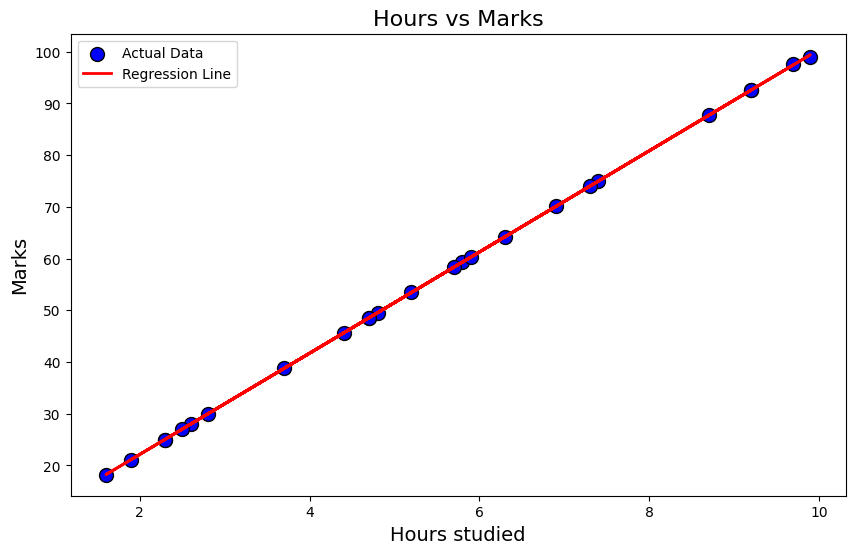

In [11]:
# plotting the regression line
line = regressor.coef_ * x + regressor.intercept_

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
line = regressor.coef_ * x + regressor.intercept_
plt.scatter(x, y, color='blue', edgecolors='black', s=100, label='Actual Data')
plt.plot(x, line, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Hours studied', fontsize=14)
plt.ylabel('Marks', fontsize=14)
plt.title('Hours vs Marks', fontsize=16)
plt.legend()
plt.show()

In [13]:
#PREDICTING FOR A SPECFIC VALUE(EG:9.25 HOURS)
hours=float(input("Enter hours studied: "))
prediction=regressor.predict([[hours]])
print(f"Predicted marks for {hours} hours of study: {prediction[0,0]:.2f}")

Predicted marks for 6.0 hours of study: 61.27
